In [16]:
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

In [3]:
user = (
    'cgusb' if 'cgusb' in [f.stem for f in Path(r"C:\Users").iterdir()]
    else 'gusb'
)
dms_16p48_path = Path(
    fr'C:\Users\{user}\Research\mhe-analysis\results'
    r'\ct-verif-16p48-4msd-grainstats\grainstats_dms.npy'
)
dms_8p24_path = Path(
    fr'C:\Users\{user}\Research\mhe-analysis\results'
    r'\ct-verif-8p24-8msd-grainstats\grainstats_dms.npy'
)
dms_4p12_path = Path(
    fr'C:\Users\{user}\Research\mhe-analysis\results'
    r'\ct-verif-4p12-16msd-grainstats\grainstats_dms.npy'
)

In [4]:
dms_16p48 = np.load(dms_16p48_path)
dms_8p24 = np.load(dms_8p24_path)
dms_4p12 = np.load(dms_4p12_path)

## Develop method

In [5]:
dms_16p48.shape

(1607, 3)

In [7]:
dms_16p48[0, :]

array([181.24503735, 145.85576737, 133.57513156])

In [14]:
np.partition(dms_16p48, -2, axis=1)[:, -2]

array([145.85576737, 239.45101453, 157.59601825, ..., 187.44168527,
       270.72129752, 104.14916173])

In [17]:
np.max(dms_16p48)

805.3853162136899

## From previous code

Original notebook:

`C:\Users\gusb\Research\PSAAP\ct-verification\stlToTiff_segmentflow\grain_stats_plotted.ipynb`

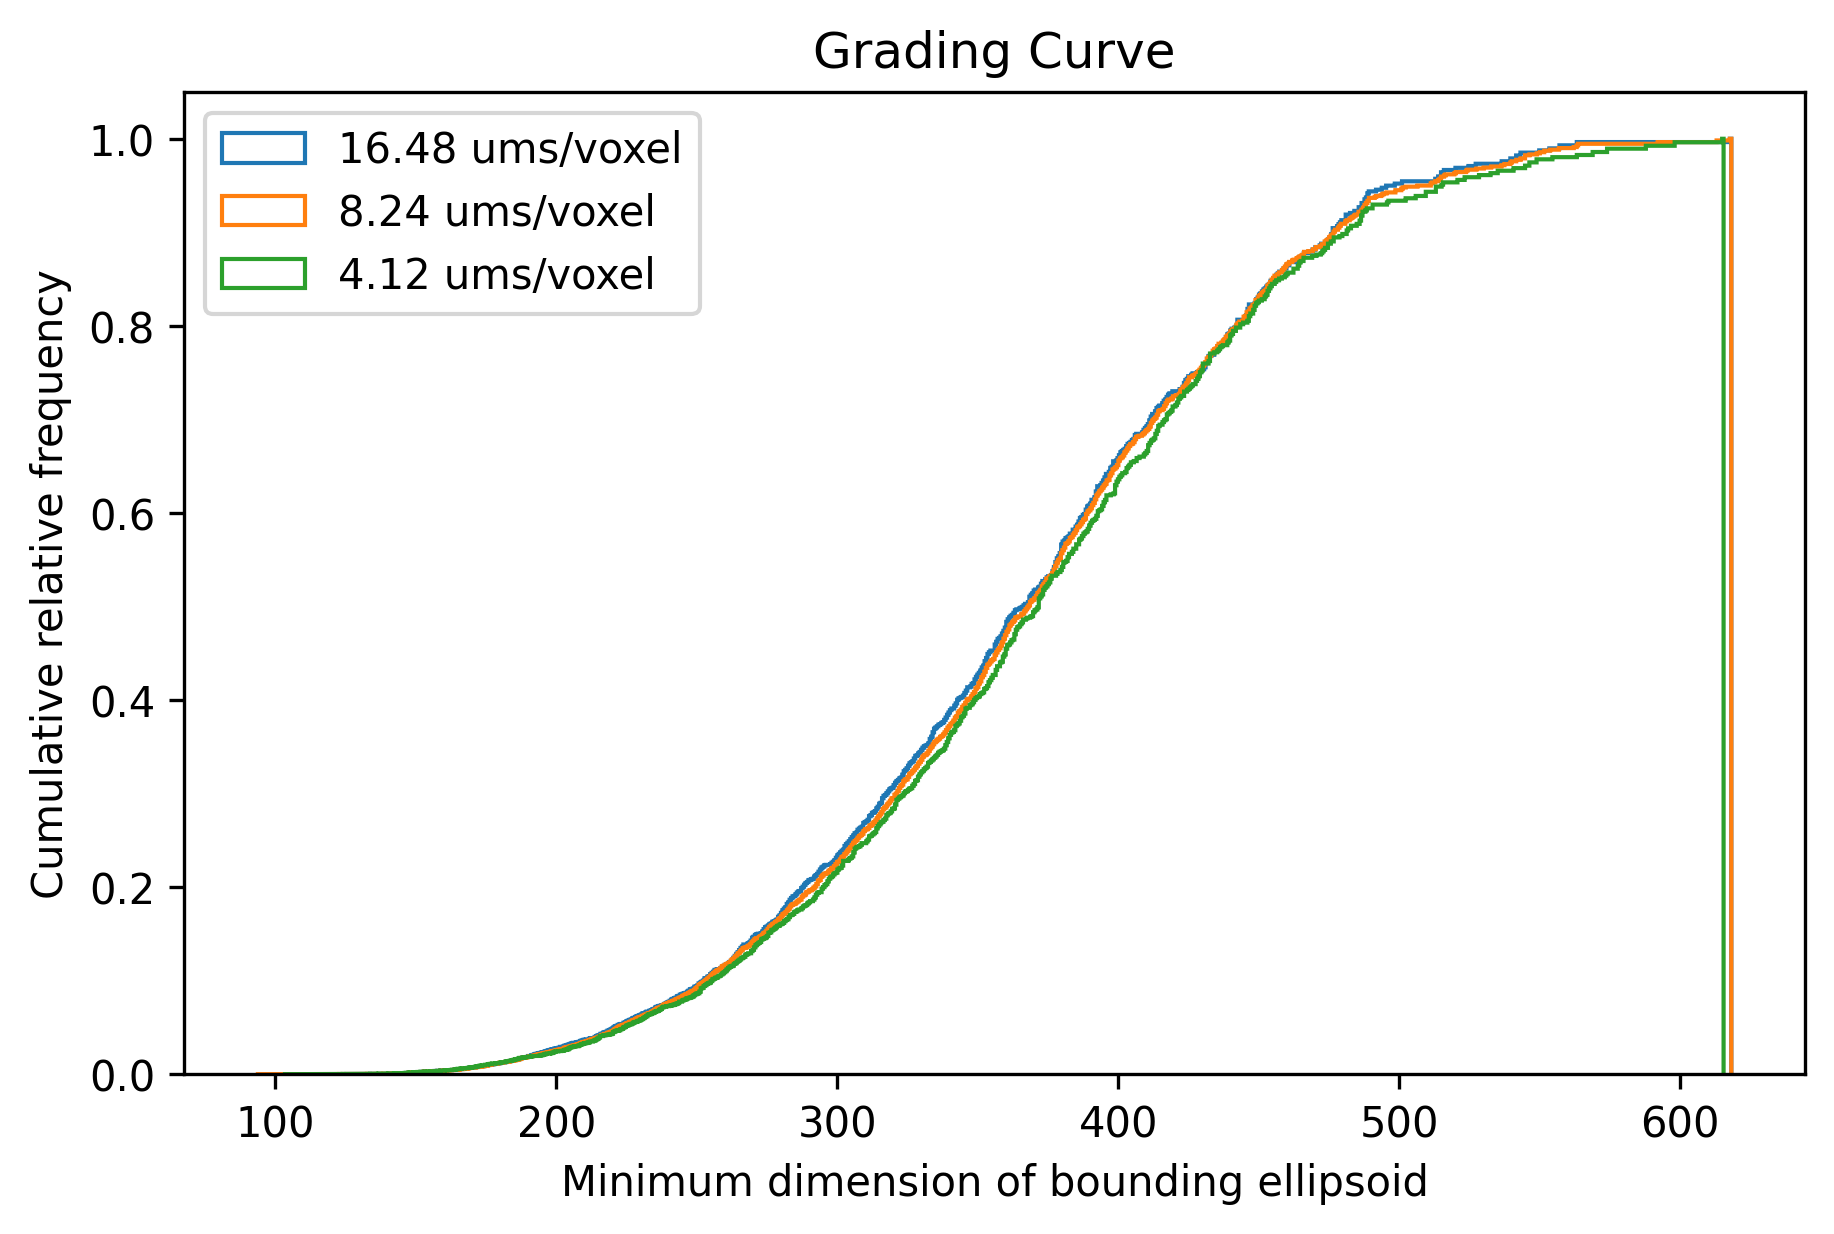

In [18]:
grain_stats_dict = {
    16.48 : Path(
        fr'C:\Users\{user}\Research\mhe-analysis\results'
        r'\ct-verif-16p48-4msd-grainstats\grainstats_dms.npy'
    ),
    8.24 : Path(
        fr'C:\Users\{user}\Research\mhe-analysis\results'
        r'\ct-verif-8p24-8msd-grainstats\grainstats_dms.npy'
    ),
    4.12 : Path(
        fr'C:\Users\{user}\Research\mhe-analysis\results'
        r'\ct-verif-4p12-16msd-grainstats\grainstats_dms.npy'
    )
}
# plot the distribution function
fig, ax = plt.subplots(dpi=300, facecolor='white', constrained_layout=True)
for spatial_res, grain_stats_path in grain_stats_dict.items():
    dms = np.load(grain_stats_path)
    min_dim = dms[:, 1]
    normalize_by_mass = True
    if normalize_by_mass:
        volume = np.product(dms, axis=1)
        volume = volume / np.max(volume)
        # Janky, but doesn't matter.
        n_repeats = np.round(volume * 100).astype(int)
        min_dim = np.repeat(min_dim, n_repeats)
    # Get percentiles 10, 30, and 60
    percentiles = np.array([10,30,60])
    [D10,D30,D60] = np.percentile(min_dim, percentiles)
    # plot the cumulative distribution function
    ax.hist(
        min_dim, bins=1000, density=True, cumulative=True, histtype='step',
        label=f'{spatial_res} ums/voxel')
    ax.set_xlabel('Minimum dimension of bounding ellipsoid')
    ax.set_ylabel('Cumulative relative frequency')
    # plot percentiles
    # ax.plot([D10,D30,D60], percentiles/100, 'ro')
    # axes[1].set_xscale('log')
    ax.set_title('Grading Curve')
ax.legend(loc='upper left')
plt.show()